In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/cleaned_superstore_orders.csv")

print("Cleaned dataset loaded successfully!")
print("Shape:", df.shape)

Cleaned dataset loaded successfully!
Shape: (20067, 21)


In [4]:
print("Dataset Information:")
print(df.info())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20067 entries, 0 to 20066
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        20067 non-null  str    
 1   order_date      20067 non-null  str    
 2   ship_date       13297 non-null  str    
 3   ship_mode       20067 non-null  str    
 4   customer_name   20067 non-null  str    
 5   segment         20067 non-null  str    
 6   state           20067 non-null  str    
 7   country         20067 non-null  str    
 8   market          20067 non-null  str    
 9   region          20067 non-null  str    
 10  product_id      20067 non-null  str    
 11  category        20067 non-null  str    
 12  sub_category    20067 non-null  str    
 13  product_name    20067 non-null  str    
 14  sales           20067 non-null  str    
 15  quantity        20067 non-null  int64  
 16  discount        20067 non-null  float64
 17  profit          20067

,quantity,discount,profit,shipping_cost,year
count,20067.000000,20067.000000,20067.000000,20067.000000,20067.000000
mean,3.460856,0.143832,28.788174,25.829576,2012.776598
std,2.269055,0.212766,171.555022,55.684726,1.100490
min,1.000000,0.000000,-3839.990400,0.010000,2011.000000
25%,2.000000,0.000000,0.000000,2.670000,2012.000000
50%,3.000000,0.000000,9.238600,7.760000,2013.000000
75%,5.000000,0.200000,36.480000,24.300000,2014.000000
max,14.000000,0.800000,8399.976000,923.630000,2014.000000


In [5]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing[missing > 0])

Missing Values:
ship_date    6770
dtype: int64


In [6]:
df["ship_date"] = df["ship_date"].fillna(df["order_date"])

print("Missing ship dates after handling:")
print(df["ship_date"].isnull().sum())

Missing ship dates after handling:
0


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
# Convert numeric columns to numbers
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["profit"] = pd.to_numeric(df["profit"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

print("Numeric columns converted successfully!")
print(df[["sales", "profit", "quantity"]].dtypes)

Numeric columns converted successfully!
sales       float64
profit      float64
quantity      int64
dtype: object


In [10]:
print("Total Sales:", round(df["sales"].sum(), 2))
print("Total Profit:", round(df["profit"].sum(), 2))
print("Total Quantity Sold:", df["quantity"].sum())

Total Sales: 3075011.0
Total Profit: 577692.29
Total Quantity Sold: 69449


In [11]:
category_analysis = df.groupby("category").agg(
    Total_Sales=("sales", "sum"),
    Total_Profit=("profit", "sum"),
    Total_Quantity=("quantity", "sum")
).round(2)

category_analysis = category_analysis.sort_values(
    by="Total_Sales",
    ascending=False
)

display(category_analysis)

,Total_Sales,Total_Profit,Total_Quantity
category,,,
Office Supplies,1076802.0,200220.80,41994
Technology,1064704.0,268088.13,13904
Furniture,933505.0,109383.36,13551


In [12]:
category_analysis["Profit_Margin_%"] = (
    category_analysis["Total_Profit"] /
    category_analysis["Total_Sales"] * 100
).round(2)

display(category_analysis)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
category,,,,
Office Supplies,1076802.0,200220.80,41994,18.59
Technology,1064704.0,268088.13,13904,25.18
Furniture,933505.0,109383.36,13551,11.72


In [13]:
region_analysis = df.groupby("region").agg(
    Total_Sales=("sales", "sum"),
    Total_Profit=("profit", "sum"),
    Total_Quantity=("quantity", "sum")
).round(2)

region_analysis["Profit_Margin_%"] = (
    region_analysis["Total_Profit"] /
    region_analysis["Total_Sales"] * 100
).round(2)

region_analysis = region_analysis.sort_values(
    by="Total_Profit",
    ascending=False
)

display(region_analysis)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
region,,,,
Central,706199.0,118315.51,16439,16.75
North Asia,177914.0,70701.56,3537,39.74
North,306787.0,65081.20,6946,21.21
Central Asia,155381.0,56172.67,3080,36.15
South,388001.0,55265.53,9593,14.24
Oceania,241780.0,49001.99,4825,20.27
East,152998.0,41474.25,4109,27.11
West,157110.0,41257.32,4755,26.26
Africa,206189.0,30179.21,4075,14.64


In [14]:
year_analysis = df.groupby("year").agg(
    Total_Sales=("sales", "sum"),
    Total_Profit=("profit", "sum"),
    Total_Quantity=("quantity", "sum")
).round(2)

year_analysis["Profit_Margin_%"] = (
    year_analysis["Total_Profit"] /
    year_analysis["Total_Sales"] * 100
).round(2)

display(year_analysis)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
year,,,,
2011,551280.0,113534.54,12493,20.59
2012,641491.0,117606.91,14624,18.33
2013,847235.0,169899.98,18889,20.05
2014,1035005.0,176650.86,23443,17.07


In [15]:
discount_analysis = df.groupby("discount").agg(
    Total_Sales=("sales", "sum"),
    Total_Profit=("profit", "sum"),
    Total_Quantity=("quantity", "sum")
).round(2)

discount_analysis["Profit_Margin_%"] = (
    discount_analysis["Total_Profit"] /
    discount_analysis["Total_Sales"] * 100
).round(2)

display(discount_analysis)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
discount,,,,
0.000,1689142.0,698719.36,38617,41.37
0.002,64043.0,21691.25,580,33.87
0.070,26024.0,8386.55,225,32.23
0.100,334418.0,98489.56,5768,29.45
0.150,64174.0,11168.57,758,17.40
0.170,49696.0,13253.18,1068,26.67
0.200,297861.0,42003.47,7611,14.10
0.202,5736.0,-352.48,59,-6.15
0.250,22185.0,-114.79,334,-0.52


In [16]:
subcategory_analysis = df.groupby("sub_category").agg(
    Total_Sales=("sales", "sum"),
    Total_Profit=("profit", "sum"),
    Total_Quantity=("quantity", "sum")
)

subcategory_analysis["Profit_Margin_%"] = (
    subcategory_analysis["Total_Profit"]
    / subcategory_analysis["Total_Sales"] * 100
).round(2)

subcategory_analysis = subcategory_analysis.sort_values(
    by="Total_Profit",
    ascending=False
)

display(subcategory_analysis)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
sub_category,,,,
Copiers,313333.0,106751.6661,2972,34.07
Phones,352774.0,81576.5767,4542,23.12
Appliances,145225.0,60736.0306,2439,41.82
Bookcases,311225.0,58998.4439,3189,18.96
Chairs,356470.0,54534.5677,4803,15.30
Accessories,226860.0,51222.6491,4435,22.58
Storage,349562.0,43363.4301,6588,12.41
Machines,171737.0,28537.2397,1955,16.62
Art,146617.0,23447.2647,6445,15.99


In [17]:
top_products = df.groupby("product_name").agg(
    Total_Sales=("sales", "sum"),
    Total_Profit=("profit", "sum"),
    Total_Quantity=("quantity", "sum")
).round(2)

top_products = top_products.sort_values(
    by="Total_Profit",
    ascending=False
).head(10)

display(top_products)

,Total_Sales,Total_Profit,Total_Quantity
product_name,,,
"Hoover Stove, Red",1080.0,9538.38,38
Canon imageCLASS 2200 Advanced Copier,0.0,8399.98,5
Hewlett Packard LaserJet 3310 Copier,960.0,4607.92,21
"Dania Classic Bookcase, Pine",2964.0,4549.01,46
"Nokia Smart Phone, with Caller ID",1406.0,4156.66,40
"Cisco Smart Phone, Full Size",2999.0,4108.33,36
"Cisco Smart Phone, with Caller ID",2878.0,4007.95,40
"Canon Wireless Fax, Laser",1893.0,3717.75,27
"Samsung Smart Phone, with Caller ID",2205.0,3712.58,26


In [18]:
loss_products = df.groupby("product_name").agg(
    Total_Sales=("sales", "sum"),
    Total_Profit=("profit", "sum"),
    Total_Quantity=("quantity", "sum")
).round(2)

loss_products = loss_products.sort_values(
    by="Total_Profit",
    ascending=True
).head(10)

display(loss_products)

,Total_Sales,Total_Profit,Total_Quantity
product_name,,,
"Hoover Stove, White",567.0,-5700.56,39
Cubify CubeX 3D Printer Triple Head Print,0.0,-3839.99,4
"Samsung Smart Phone, Cordless",1534.0,-3243.99,68
Ibico EPK-21 Electric Binding System,0.0,-2929.48,5
"Lesro Round Table, Adjustable Height",2280.0,-2302.99,13
"Lesro Computer Table, Fully Assembled",1800.0,-1924.73,13
"Chromcraft Conference Table, with Bottom Storage",1397.0,-1815.32,14
"Bevis Computer Table, Fully Assembled",3820.0,-1793.11,16
"Eldon Lockers, Blue",5176.0,-1723.28,64


In [19]:
segment_analysis = df.groupby("segment").agg(
    Total_Sales=("sales", "sum"),
    Total_Profit=("profit", "sum"),
    Total_Quantity=("quantity", "sum")
).round(2)

segment_analysis["Profit_Margin_%"] = (
    segment_analysis["Total_Profit"] /
    segment_analysis["Total_Sales"] * 100
).round(2)

segment_analysis = segment_analysis.sort_values(
    by="Total_Profit",
    ascending=False
)

display(segment_analysis)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
segment,,,,
Consumer,1608468.0,292822.74,36268,18.21
Corporate,914773.0,175277.74,20602,19.16
Home Office,551770.0,109591.80,12579,19.86


In [20]:
shipping_analysis = df.groupby("ship_mode").agg(
    Total_Sales=("sales", "sum"),
    Total_Profit=("profit", "sum"),
    Total_Quantity=("quantity", "sum")
).round(2)

shipping_analysis["Profit_Margin_%"] = (
    shipping_analysis["Total_Profit"] /
    shipping_analysis["Total_Sales"] * 100
).round(2)

shipping_analysis = shipping_analysis.sort_values(
    by="Total_Profit",
    ascending=False
)

display(shipping_analysis)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
ship_mode,,,,
Standard Class,1874861.0,345709.98,42315,18.44
Second Class,596298.0,112168.98,13134,18.81
First Class,453716.0,89121.79,10491,19.64
Same Day,150136.0,30691.54,3509,20.44


In [21]:
priority_analysis = df.groupby("order_priority").agg(
    Total_Sales=("sales", "sum"),
    Total_Profit=("profit", "sum"),
    Total_Quantity=("quantity", "sum")
).round(2)

priority_analysis["Profit_Margin_%"] = (
    priority_analysis["Total_Profit"] /
    priority_analysis["Total_Sales"] * 100
).round(2)

priority_analysis = priority_analysis.sort_values(
    by="Total_Sales",
    ascending=False
)

display(priority_analysis)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
order_priority,,,,
Medium,1784286.0,325269.25,40272,18.23
High,915268.0,163725.19,20803,17.89
Critical,234466.0,60613.26,5392,25.85
Low,140991.0,28084.60,2982,19.92


In [22]:
overall_profit_margin = (
    df["profit"].sum() / df["sales"].sum()
) * 100

print("Overall Profit Margin:", round(overall_profit_margin, 2), "%")

Overall Profit Margin: 18.79 %


In [24]:
zero_sales = df[df["sales"] == 0]

print("Records with zero sales:", len(zero_sales))
print("\nProfit on zero-sales records:")
print(zero_sales["profit"].sum())

display(
    zero_sales[["product_name", "sales", "profit", "quantity"]].head(10)
)

Records with zero sales: 0

Profit on zero-sales records:
0.0


,product_name,sales,profit,quantity


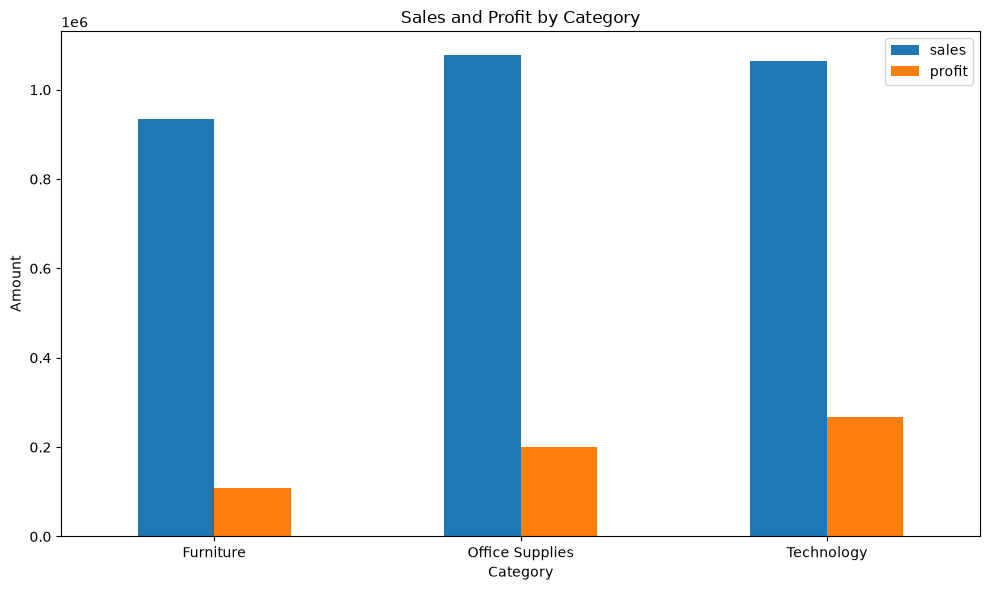

In [25]:
import matplotlib.pyplot as plt

category_chart = df.groupby("category")[["sales", "profit"]].sum()

category_chart.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

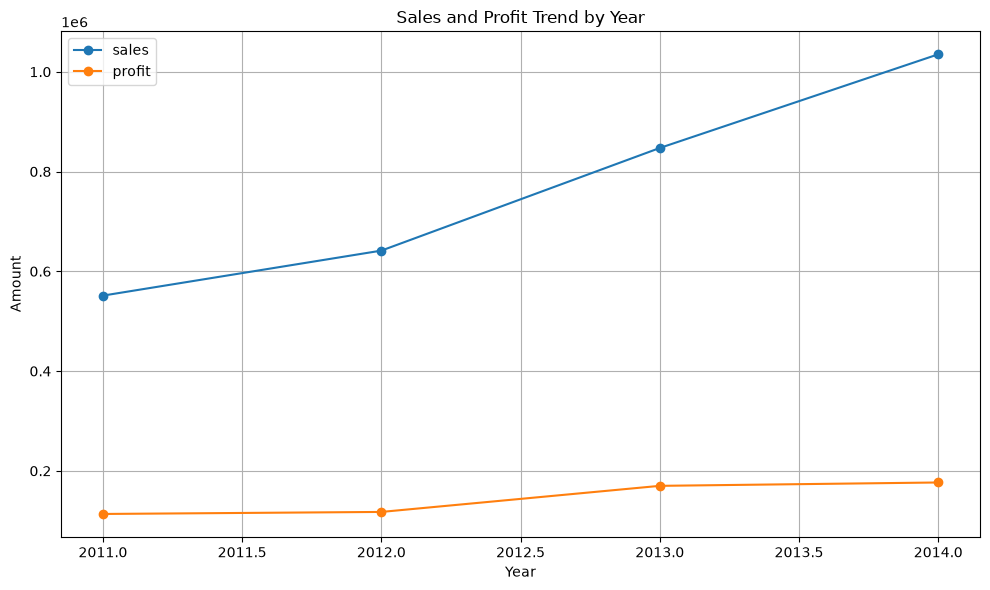

In [26]:
year_chart = df.groupby("year")[["sales", "profit"]].sum()

year_chart.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Sales and Profit Trend by Year")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.grid(True)
plt.tight_layout()
plt.show()

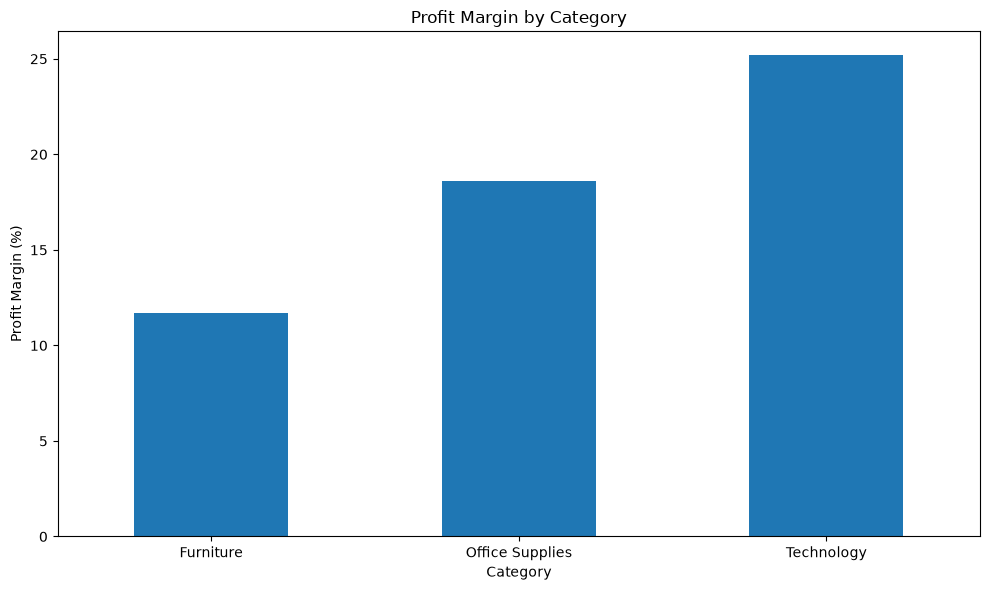

In [27]:
category_margin = (
    df.groupby("category")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum")
      )
)

category_margin["Profit_Margin_%"] = (
    category_margin["Total_Profit"]
    / category_margin["Total_Sales"]
    * 100
)

category_margin["Profit_Margin_%"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

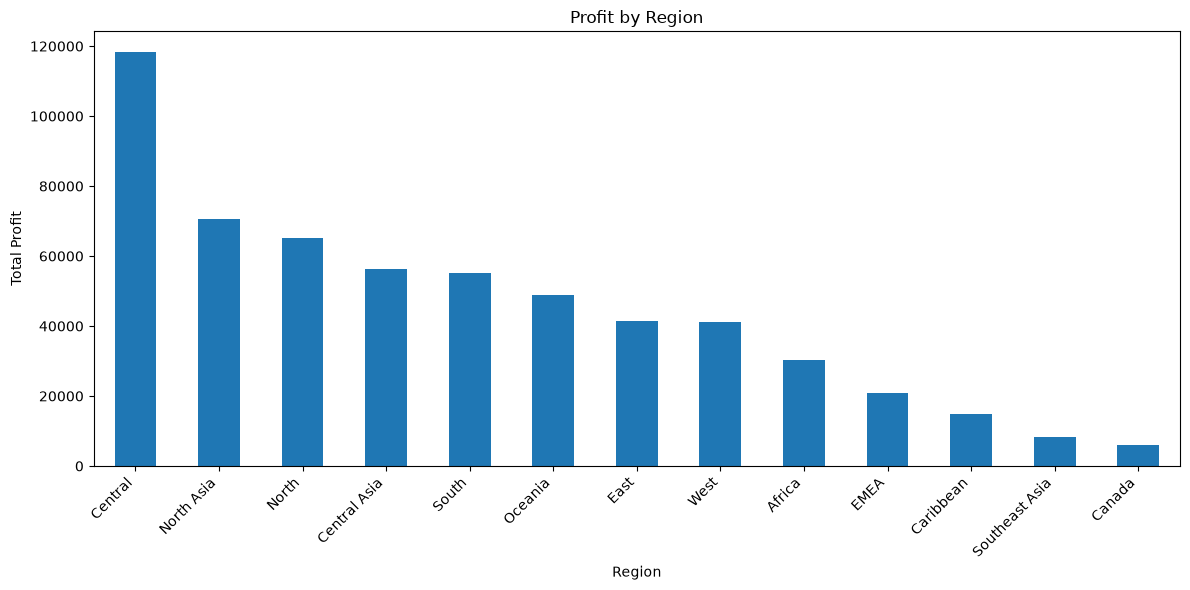

In [28]:
region_profit = df.groupby("region")["profit"].sum().sort_values(ascending=False)

region_profit.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

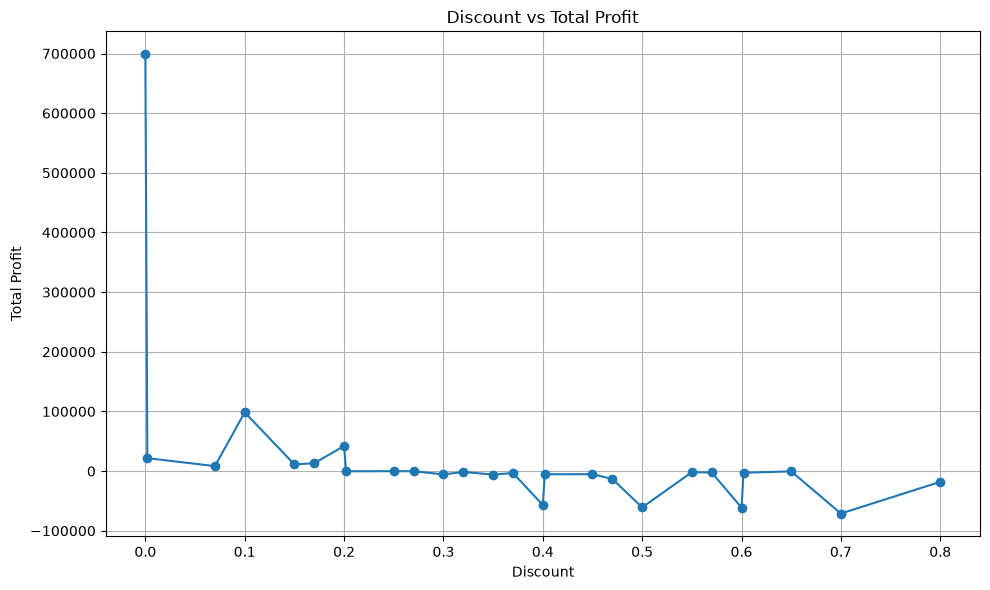

In [29]:
discount_profit = df.groupby("discount")["profit"].sum()

discount_profit.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Discount vs Total Profit")
plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
top_products = (
    df.groupby("product_name")["profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("Top 10 Most Profitable Products:")
print(top_products)

Top 10 Most Profitable Products:
product_name
Hoover Stove, Red                        9538.3770
Canon imageCLASS 2200 Advanced Copier    8399.9760
Hewlett Packard LaserJet 3310 Copier     4607.9232
Dania Classic Bookcase, Pine             4549.0146
Nokia Smart Phone, with Caller ID        4156.6550
Cisco Smart Phone, Full Size             4108.3286
Cisco Smart Phone, with Caller ID        4007.9548
Canon Wireless Fax, Laser                3717.7500
Samsung Smart Phone, with Caller ID      3712.5815
Hamilton Beach Stove, Silver             3671.1270
Name: profit, dtype: float64


In [31]:
loss_products = (
    df.groupby("product_name")["profit"]
      .sum()
      .sort_values()
      .head(10)
)

print("Top 10 Loss-Making Products:")
print(loss_products)

Top 10 Loss-Making Products:
product_name
Hoover Stove, White                                    -5700.5607
Cubify CubeX 3D Printer Triple Head Print              -3839.9904
Samsung Smart Phone, Cordless                          -3243.9900
Ibico EPK-21 Electric Binding System                   -2929.4845
Lesro Round Table, Adjustable Height                   -2302.9860
Lesro Computer Table, Fully Assembled                  -1924.7320
Chromcraft Conference Table, with Bottom Storage       -1815.3180
Bevis Computer Table, Fully Assembled                  -1793.1072
Eldon Lockers, Blue                                    -1723.2794
Bush Advantage Collection Racetrack Conference Table   -1578.0612
Name: profit, dtype: float64


# Business Insights & Recommendations

## Key Insights

1. The overall business generated total sales of 3,075,011 and total profit of 577,692.29, with an overall profit margin of 18.79%.

2. Technology is the most profitable category with a profit margin of 25.18%, while Furniture has the lowest profit margin at 11.72%.

3. Sales increased continuously from 551,280 in 2011 to 1,035,005 in 2014, showing strong business growth.

4. Although sales increased, profit margin declined from 20.59% in 2011 to 17.07% in 2014, indicating a need to improve profitability efficiency.

5. Higher discounts are associated with lower profitability. Discounts of 30% and above resulted in negative overall profit for several discount levels.

6. Product-level analysis identified both highly profitable and loss-making products, showing that product-specific pricing and discount strategies are important.

## Recommendations

- Focus more on high-performing Technology products.
- Review the pricing and discount strategy for Furniture.
- Avoid excessive discounts that negatively affect profitability.
- Investigate loss-making products before promoting them.
- Monitor profit margin along with sales growth to maintain healthy profitability.

# Final KPI Summary

| KPI                           |      Value |
| ----------------------------- | ---------: |
| Total Sales                   |  3,075,011 |
| Total Profit                  | 577,692.29 |
| Overall Profit Margin         |     18.79% |
| Best Performing Category      | Technology |
| Technology Profit Margin      |     25.18% |
| Lowest Profit Margin Category |  Furniture |
| Furniture Profit Margin       |     11.72% |
| Highest Sales Year            |       2014 |
| Sales in 2014                 |  1,035,005 |
| Sales in 2011                 |    551,280 |

## Project Summary

The analysis shows that the business achieved strong sales growth between 2011 and 2014. However, the decline in profit margin indicates that increasing sales alone does not guarantee higher profitability. Technology performed strongly in terms of profitability, while Furniture requires improvement in pricing and discount strategies. The analysis also highlights the negative impact of excessive discounts on profit.

## Overall Business Conclusion

The business is growing in terms of sales, but profitability should be improved through better discount management, category-level pricing strategies, and careful monitoring of loss-making products.
